In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('IRIS.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [11]:
# cek ada data kosong atau engga
print(df.isnull().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [12]:
print(f"Jumlah duplikat: {df.duplicated().sum()}")
print(df[df.duplicated(keep=False)]) # tampilin baris yg duplikat

df = df.drop_duplicates().reset_index(drop=True)
print(f"Setelah dihapus: {len(df)} baris")

Jumlah duplikat: 3
     sepal_length  sepal_width  petal_length  petal_width         species
9             4.9          3.1           1.5          0.1     Iris-setosa
34            4.9          3.1           1.5          0.1     Iris-setosa
37            4.9          3.1           1.5          0.1     Iris-setosa
101           5.8          2.7           5.1          1.9  Iris-virginica
142           5.8          2.7           5.1          1.9  Iris-virginica
Setelah dihapus: 147 baris


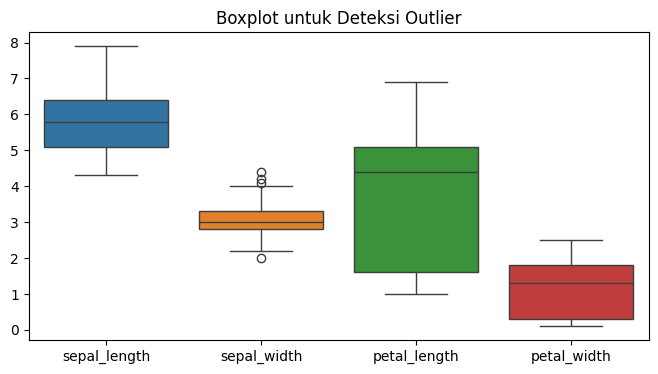

In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.title("Boxplot untuk Deteksi Outlier")
plt.show()

# dari boxplot kelihatan sepal_width ada outlier, jadi di-capping pake IQR
Q1 = df['sepal_width'].quantile(0.25)
Q3 = df['sepal_width'].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

df['sepal_width'] = np.clip(df['sepal_width'], batas_bawah, batas_atas) # clip biar outliernya dibatesin

In [14]:
df['petal_area'] = df['petal_length'] * df['petal_width'] # fitur baru: luas petal

# bagi jadi 3 kategori biar nanti bisa di ordinal encoding
df['petal_size'] = pd.qcut(df['petal_area'], q=3, labels=['Kecil', 'Sedang', 'Besar'])

df[['petal_length', 'petal_width', 'petal_area', 'petal_size']].head()

,petal_length,petal_width,petal_area,petal_size
0,1.4,0.2,0.28,Kecil
1,1.4,0.2,0.28,Kecil
2,1.3,0.2,0.26,Kecil
3,1.5,0.2,0.30,Kecil
4,1.4,0.2,0.28,Kecil


In [15]:
kolom_angka = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'petal_area']

scaler = StandardScaler()
df_scaled = df.copy() # copy dulu biar data asli ga ketimpa
df_scaled[kolom_angka] = scaler.fit_transform(df[kolom_angka])

print(df_scaled[kolom_angka].mean()) # harusnya deket 0
df_scaled[kolom_angka].head()

sepal_length   -4.833624e-17
sepal_width     4.350262e-16
petal_length   -2.416812e-16
petal_width    -3.383537e-16
petal_area      3.866899e-16
dtype: float64


,sepal_length,sepal_width,petal_length,petal_width,petal_area
0,-0.915509,1.053523,-1.357737,-1.3357,-1.186654
1,-1.157560,-0.123285,-1.357737,-1.3357,-1.186654
2,-1.399610,0.347438,-1.414778,-1.3357,-1.190920
3,-1.520635,0.112077,-1.300696,-1.3357,-1.182388
4,-1.036535,1.288885,-1.357737,-1.3357,-1.186654


In [16]:
# petal_size ada urutannya jadi pake ordinal
urutan = {'Kecil': 0, 'Sedang': 1, 'Besar': 2}
df_scaled['petal_size_encoded'] = df_scaled['petal_size'].map(urutan)

In [17]:
df_final = pd.get_dummies(df_scaled, columns=['species'], prefix='species', dtype=int) # one-hot soalnya species ga ada urutannya
df_final.head()

,sepal_length,sepal_width,petal_length,petal_width,petal_area,petal_size,petal_size_encoded,species_Iris-setosa,species_Iris-versicolor,species_Iris-virginica
0,-0.915509,1.053523,-1.357737,-1.3357,-1.186654,Kecil,0,1,0,0
1,-1.157560,-0.123285,-1.357737,-1.3357,-1.186654,Kecil,0,1,0,0
2,-1.399610,0.347438,-1.414778,-1.3357,-1.190920,Kecil,0,1,0,0
3,-1.520635,0.112077,-1.300696,-1.3357,-1.182388,Kecil,0,1,0,0
4,-1.036535,1.288885,-1.357737,-1.3357,-1.186654,Kecil,0,1,0,0
